In [4]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

import tensorflow
from tensorflow import keras
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense

In [5]:
df = pd.read_csv('/content/Churn_Modelling.csv')

In [6]:
df

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,9996,15606229,Obijiaku,771,France,Male,39,5,0.00,2,1,0,96270.64,0
9996,9997,15569892,Johnstone,516,France,Male,35,10,57369.61,1,1,1,101699.77,0
9997,9998,15584532,Liu,709,France,Female,36,7,0.00,1,0,1,42085.58,1
9998,9999,15682355,Sabbatini,772,Germany,Male,42,3,75075.31,2,1,0,92888.52,1


In [7]:
df.drop(columns=['RowNumber', 'CustomerId', 'Surname'], inplace=True)

In [8]:
df = pd.get_dummies(df, columns=['Geography', 'Gender'], drop_first=True)

In [9]:
df

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_Germany,Geography_Spain,Gender_Male
0,619,42,2,0.00,1,1,1,101348.88,1,False,False,False
1,608,41,1,83807.86,1,0,1,112542.58,0,False,True,False
2,502,42,8,159660.80,3,1,0,113931.57,1,False,False,False
3,699,39,1,0.00,2,0,0,93826.63,0,False,False,False
4,850,43,2,125510.82,1,1,1,79084.10,0,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...
9995,771,39,5,0.00,2,1,0,96270.64,0,False,False,True
9996,516,35,10,57369.61,1,1,1,101699.77,0,False,False,True
9997,709,36,7,0.00,1,0,1,42085.58,1,False,False,False
9998,772,42,3,75075.31,2,1,0,92888.52,1,True,False,True


In [10]:
x = df.drop('Exited', axis = 1)
y = df['Exited'].values

In [11]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=0)

In [12]:
scaler = StandardScaler()

x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

In [48]:
Model = Sequential()

Model.add(Dense(11, activation='tanh', input_dim = 11))
Model.add(Dense(11, activation='tanh'))
Model.add(Dense(1, activation='sigmoid'))

In [49]:
Model.compile(optimizer='Adam', loss='binary_crossentropy', metrics=['accuracy'])

In [50]:
Model.summary()

Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_18 (Dense)                     │ (None, 11)                  │             132 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_19 (Dense)                     │ (None, 11)                  │             132 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_20 (Dense)                     │ (None, 1)                   │              12 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 276 (1.08 KB)

 Trainable params: 276 (1.08 KB)

 Non-trainable params: 0 (0.00 B)

In [51]:
history = Model.fit(x_train, y_train, validation_split=0.33, batch_size=32, epochs=100)

Epoch 1/100
168/168 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.6363 - loss: 0.6339 - val_accuracy: 0.7970 - val_loss: 0.4768
Epoch 2/100
168/168 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8023 - loss: 0.4518 - val_accuracy: 0.8046 - val_loss: 0.4304
Epoch 3/100
168/168 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8106 - loss: 0.4223 - val_accuracy: 0.8103 - val_loss: 0.4230
Epoch 4/100
168/168 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8193 - loss: 0.4146 - val_accuracy: 0.8114 - val_loss: 0.4159
Epoch 5/100
168/168 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8165 - loss: 0.4078 - val_accuracy: 0.8190 - val_loss: 0.4076
Epoch 6/100
168/168 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8260 - loss: 0.3973 - val_accuracy: 0.8224 - val_loss: 0.3988
Epoch 7/100
168/168 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8321 - loss: 0.3888 - val_accuracy: 0.8270 - val_loss: 0.3922
Epoch 8/100
168/168 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8357 - loss: 0.3778 - val_accu

Text(0.5, 0, 'Epoch')

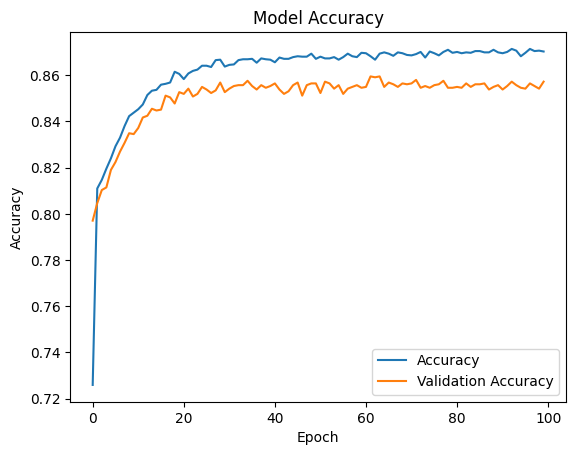

In [52]:
plt.plot(history.history['accuracy'], label = "Accuracy")
plt.plot(history.history['val_accuracy'], label = "Validation Accuracy")
plt.legend()
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')

Text(0.5, 0, 'Epoch')

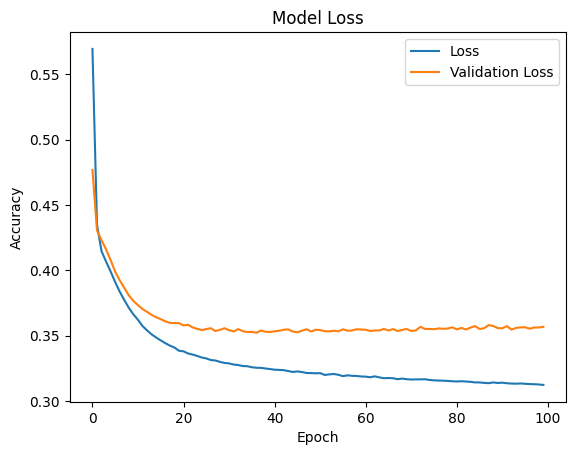

In [53]:
plt.plot(history.history['loss'], label = "Loss")
plt.plot(history.history['val_loss'], label = "Validation Loss")

plt.legend()
plt.title('Model Loss')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')

In [19]:
Model1 = Sequential()

Model1.add(Dense(11, activation='relu', input_dim = 11))
Model1.add(Dense(11, activation='relu'))
Model1.add(Dense(1, activation='sigmoid'))

In [20]:
Model1.compile(optimizer='Adam', loss='binary_crossentropy', metrics=['accuracy'])

In [21]:
Model1.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                      │ (None, 11)                  │             132 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 11)                  │             132 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 1)                   │              12 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 276 (1.08 KB)

 Trainable params: 276 (1.08 KB)

 Non-trainable params: 0 (0.00 B)

In [22]:
history1 = Model1.fit(x_train, y_train, validation_split=0.33, batch_size=32, epochs=100)

Epoch 1/100
168/168 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7258 - loss: 0.5911 - val_accuracy: 0.7955 - val_loss: 0.4727
Epoch 2/100
168/168 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7934 - loss: 0.4667 - val_accuracy: 0.7955 - val_loss: 0.4501
Epoch 3/100
168/168 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8058 - loss: 0.4272 - val_accuracy: 0.8008 - val_loss: 0.4375
Epoch 4/100
168/168 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8060 - loss: 0.4286 - val_accuracy: 0.8103 - val_loss: 0.4270
Epoch 5/100
168/168 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8119 - loss: 0.4287 - val_accuracy: 0.8145 - val_loss: 0.4191
Epoch 6/100
168/168 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8288 - loss: 0.3932 - val_accuracy: 0.8186 - val_loss: 0.4113
Epoch 7/100
168/168 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8337 - loss: 0.3836 - val_accuracy: 0.8217 - val_loss: 0.4047
Epoch 8/100
168/168 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8387 - loss: 0.3761 - val_accu

Text(0.5, 0, 'Epoch')

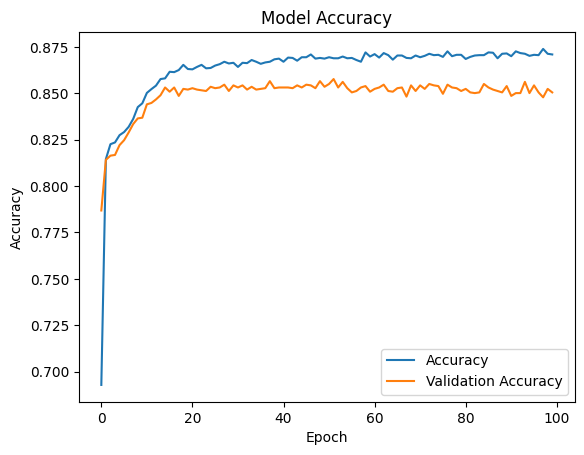

In [23]:
plt.plot(history1.history['accuracy'], label = "Accuracy")
plt.plot(history1.history['val_accuracy'], label = "Validation Accuracy")
plt.legend()
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')

Text(0.5, 0, 'Epoch')

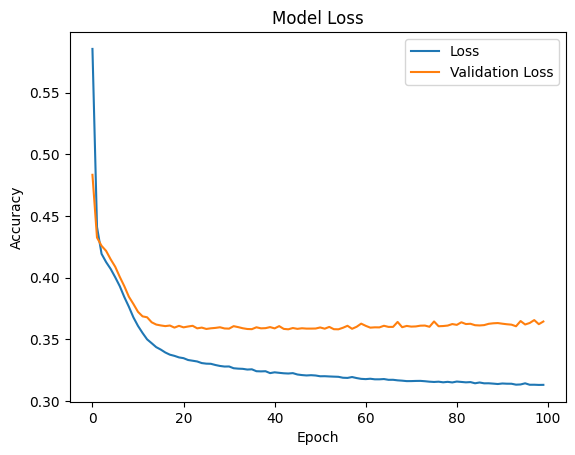

In [24]:
plt.plot(history1.history['loss'], label = "Loss")
plt.plot(history1.history['val_loss'], label = "Validation Loss")

plt.legend()
plt.title('Model Loss')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')

In [25]:
Model2 = Sequential()

Model2.add(Dense(11, activation = 'leaky_relu', input_dim = 11))
Model2.add(Dense(11, activation = 'leaky_relu'))
Model2.add(Dense(1, activation = 'sigmoid'))

In [26]:
Model2.compile(optimizer='Adam', loss='binary_crossentropy', metrics=['accuracy'])

In [27]:
Model2.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                      │ (None, 11)                  │             132 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_7 (Dense)                      │ (None, 11)                  │             132 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_8 (Dense)                      │ (None, 1)                   │              12 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 276 (1.08 KB)

 Trainable params: 276 (1.08 KB)

 Non-trainable params: 0 (0.00 B)

In [28]:
history2 = Model2.fit(x_train, y_train, validation_split=0.33, batch_size=32, epochs=100)

Epoch 1/100
168/168 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.5684 - loss: 0.6979 - val_accuracy: 0.7925 - val_loss: 0.4958
Epoch 2/100
168/168 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7988 - loss: 0.4720 - val_accuracy: 0.7993 - val_loss: 0.4512
Epoch 3/100
168/168 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8046 - loss: 0.4384 - val_accuracy: 0.8035 - val_loss: 0.4399
Epoch 4/100
168/168 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8102 - loss: 0.4263 - val_accuracy: 0.7989 - val_loss: 0.4349
Epoch 5/100
168/168 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8162 - loss: 0.4201 - val_accuracy: 0.8058 - val_loss: 0.4311
Epoch 6/100
168/168 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8211 - loss: 0.4208 - val_accuracy: 0.8122 - val_loss: 0.4282
Epoch 7/100
168/168 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8200 - loss: 0.4186 - val_accuracy: 0.8152 - val_loss: 0.4249
Epoch 8/100
168/168 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8384 - loss: 0.4041 - val_accu

Text(0.5, 0, 'Epoch')

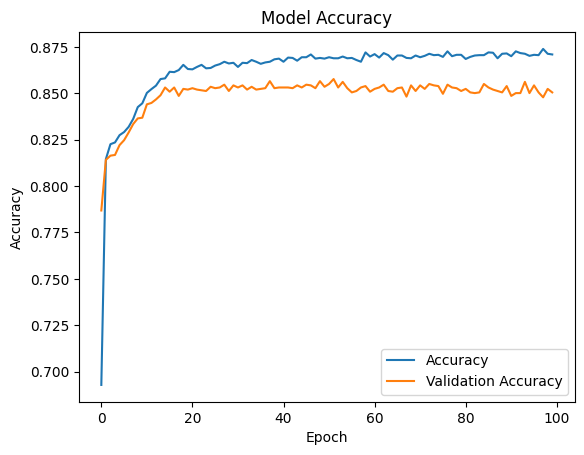

In [29]:
plt.plot(history2.history['accuracy'], label = "Accuracy")
plt.plot(history2.history['val_accuracy'], label = "Validation Accuracy")
plt.legend()
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')

Text(0.5, 0, 'Epoch')

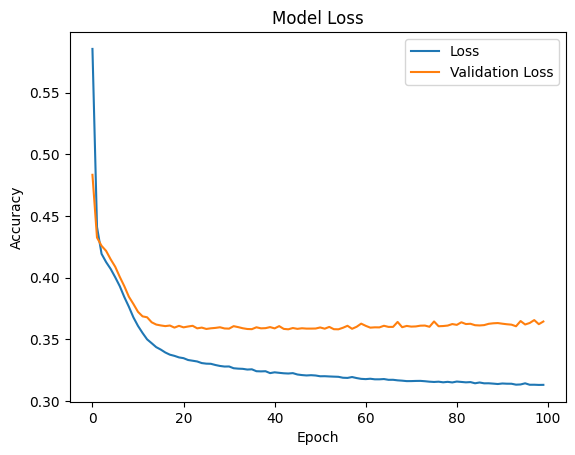

In [30]:
plt.plot(history2.history['loss'], label = "Loss")
plt.plot(history2.history['val_loss'], label = "Validation Loss")

plt.legend()
plt.title('Model Loss')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')

In [55]:
from tensorflow.keras.layers import PReLU # Import the PReLU layer

Model3 = Sequential()

Model3.add(Dense(11, input_dim = 11)) # Remove activation from Dense layer
Model3.add(PReLU()) # Add PReLU as a separate layer
Model3.add(Dense(11)) # Remove activation from Dense layer
Model3.add(PReLU()) # Add PReLU as a separate layer
Model3.add(Dense(1, activation = 'sigmoid'))

In [56]:
Model3.compile(optimizer='Adam', loss='binary_crossentropy', metrics=['accuracy'])

In [57]:
Model3.summary()

Model: "sequential_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_22 (Dense)                     │ (None, 11)                  │             132 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ p_re_lu (PReLU)                      │ (None, 11)                  │              11 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_23 (Dense)                     │ (None, 11)                  │             132 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ p_re_lu_1 (PReLU)                    │ (None, 11)                  │              11 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_24 (Dense)                     │ (None, 1)                   │              12 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 298 (1.16 KB)

 Trainable params: 298 (1.16 KB)

 Non-trainable params: 0 (0.00 B)

In [58]:
history3 = Model3.fit(x_train, y_train, validation_split=0.33, batch_size=32, epochs=100)

Epoch 1/100
168/168 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.6258 - loss: 0.6413 - val_accuracy: 0.7955 - val_loss: 0.4751
Epoch 2/100
168/168 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7948 - loss: 0.4642 - val_accuracy: 0.7955 - val_loss: 0.4467
Epoch 3/100
168/168 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8057 - loss: 0.4288 - val_accuracy: 0.8073 - val_loss: 0.4350
Epoch 4/100
168/168 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8007 - loss: 0.4329 - val_accuracy: 0.8111 - val_loss: 0.4273
Epoch 5/100
168/168 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8148 - loss: 0.4169 - val_accuracy: 0.8145 - val_loss: 0.4194
Epoch 6/100
168/168 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8162 - loss: 0.4113 - val_accuracy: 0.8183 - val_loss: 0.4088
Epoch 7/100
168/168 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8372 - loss: 0.3794 - val_accuracy: 0.8330 - val_loss: 0.3952
Epoch 8/100
168/168 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8444 - loss: 0.3726 - val_accu

Text(0.5, 0, 'Epoch')

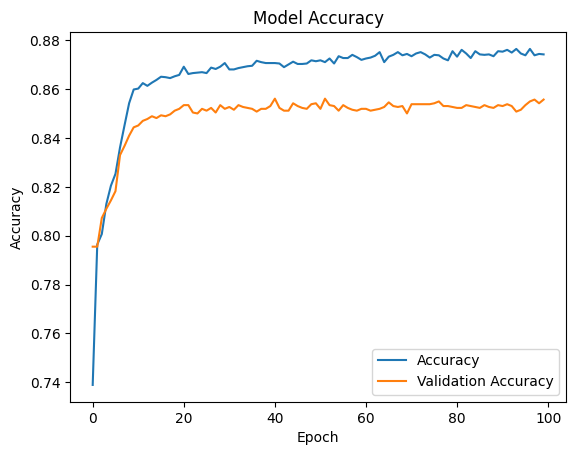

In [59]:
plt.plot(history3.history['accuracy'], label = "Accuracy")
plt.plot(history3.history['val_accuracy'], label = "Validation Accuracy")
plt.legend()
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')

Text(0.5, 0, 'Epoch')

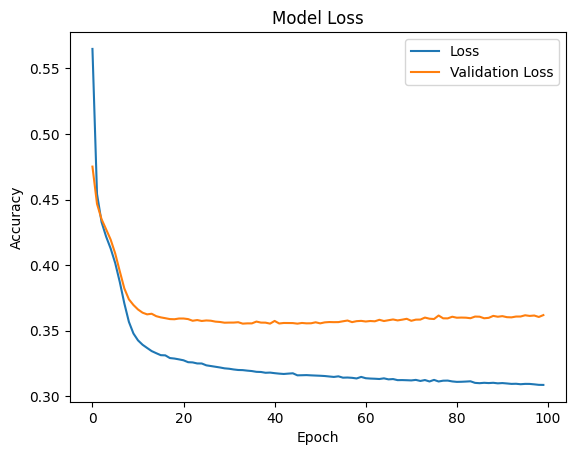

In [60]:
plt.plot(history3.history['loss'], label = "Loss")
plt.plot(history3.history['val_loss'], label = "Validation Loss")

plt.legend()
plt.title('Model Loss')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')

In [61]:
Model4 = Sequential()

Model4.add(Dense(11, activation = 'elu', input_dim = 11))
Model4.add(Dense(11, activation = 'elu'))
Model4.add(Dense(1, activation = 'sigmoid'))

In [62]:
Model4.compile(optimizer='Adam', loss='binary_crossentropy', metrics=['accuracy'])

In [63]:
Model4.summary()

Model: "sequential_11"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_25 (Dense)                     │ (None, 11)                  │             132 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_26 (Dense)                     │ (None, 11)                  │             132 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_27 (Dense)                     │ (None, 1)                   │              12 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 276 (1.08 KB)

 Trainable params: 276 (1.08 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history4 = Model4.fit(x_train, y_train, validation_split=0.33, batch_size=32, epochs=100)

Epoch 1/100
168/168 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.6060 - loss: 0.6494 - val_accuracy: 0.8050 - val_loss: 0.4615
Epoch 2/100
168/168 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8086 - loss: 0.4480 - val_accuracy: 0.8080 - val_loss: 0.4387
Epoch 3/100
168/168 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8157 - loss: 0.4302 - val_accuracy: 0.8076 - val_loss: 0.4325
Epoch 4/100
168/168 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8143 - loss: 0.4187 - val_accuracy: 0.8114 - val_loss: 0.4254
Epoch 5/100
168/168 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8187 - loss: 0.4095 - val_accuracy: 0.8160 - val_loss: 0.4162
Epoch 6/100
168/168 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8301 - loss: 0.3898 - val_accuracy: 0.8217 - val_loss: 0.4059
Epoch 7/100
168/168 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8329 - loss: 0.3870 - val_accuracy: 0.8224 - val_loss: 0.3936
Epoch 8/100
168/168 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8437 - loss: 0.3683 - val_accu

Text(0.5, 0, 'Epoch')

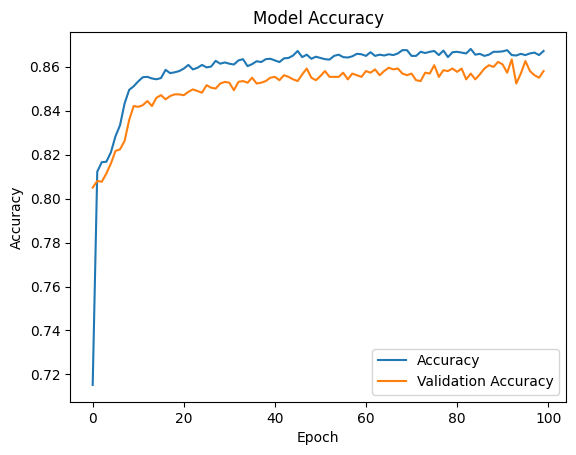

In [ ]:
plt.plot(history4.history['accuracy'], label = "Accuracy")
plt.plot(history4.history['val_accuracy'], label = "Validation Accuracy")
plt.legend()
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')

Text(0.5, 0, 'Epoch')

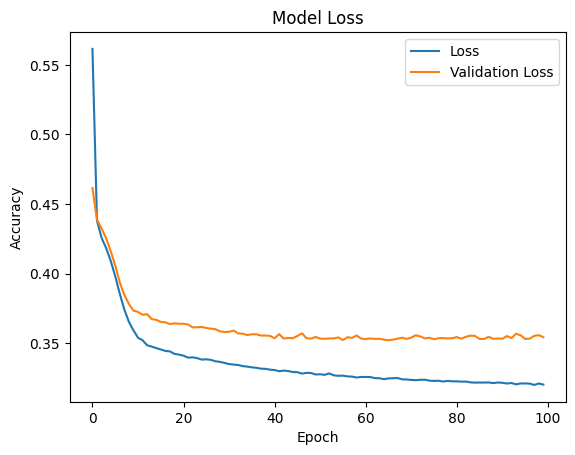

In [ ]:
plt.plot(history4.history['loss'], label = "Loss")
plt.plot(history4.history['val_loss'], label = "Validation Loss")

plt.legend()
plt.title('Model Loss')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')

In [ ]:
Model5 = Sequential()

Model5.add(Dense(11, activation = 'selu', input_dim = 11))
Model5.add(Dense(11, activation = 'selu'))
Model5.add(Dense(1, activation = 'sigmoid'))

In [ ]:
Model5.compile(optimizer='Adam', loss='binary_crossentropy', metrics=['accuracy'])

In [ ]:
Model5.summary()

Model: "sequential_12"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_28 (Dense)                     │ (None, 11)                  │             132 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_29 (Dense)                     │ (None, 11)                  │             132 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_30 (Dense)                     │ (None, 1)                   │              12 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 276 (1.08 KB)

 Trainable params: 276 (1.08 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history5 = Model5.fit(x_train, y_train, validation_split=0.33, batch_size=32, epochs=100)

Epoch 1/100
168/168 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.6128 - loss: 0.6738 - val_accuracy: 0.8122 - val_loss: 0.4437
Epoch 2/100
168/168 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8194 - loss: 0.4182 - val_accuracy: 0.8133 - val_loss: 0.4224
Epoch 3/100
168/168 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8226 - loss: 0.4100 - val_accuracy: 0.8213 - val_loss: 0.4169
Epoch 4/100
168/168 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8322 - loss: 0.3976 - val_accuracy: 0.8247 - val_loss: 0.4109
Epoch 5/100
168/168 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8347 - loss: 0.3937 - val_accuracy: 0.8277 - val_loss: 0.4053
Epoch 6/100
168/168 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8415 - loss: 0.3822 - val_accuracy: 0.8304 - val_loss: 0.3954
Epoch 7/100
168/168 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8476 - loss: 0.3730 - val_accuracy: 0.8307 - val_loss: 0.3900
Epoch 8/100
168/168 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8508 - loss: 0.3708 - val_accu

Text(0.5, 0, 'Epoch')

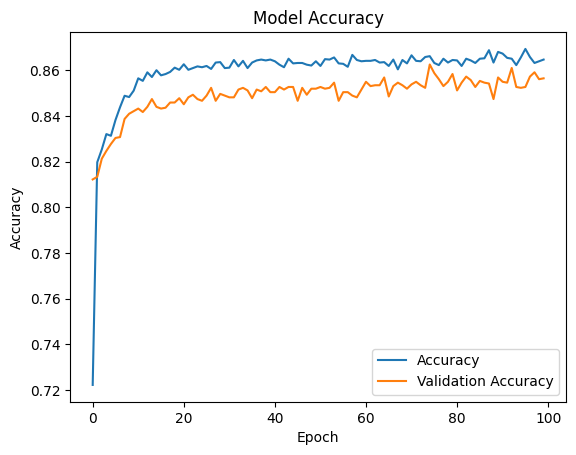

In [ ]:
plt.plot(history5.history['accuracy'], label = "Accuracy")
plt.plot(history5.history['val_accuracy'], label = "Validation Accuracy")
plt.legend()
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')

Text(0.5, 0, 'Epoch')

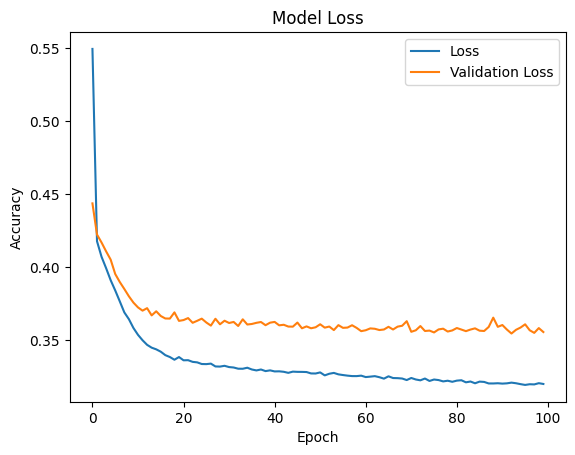

In [ ]:
plt.plot(history5.history['loss'], label = "Loss")
plt.plot(history5.history['val_loss'], label = "Validation Loss")

plt.legend()
plt.title('Model Loss')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')

1. Tanh
2. ReLU
3. Leaky ReLU
4. PReLU
5. ELU
6. SELU

Text(0.5, 0, 'Epoch')

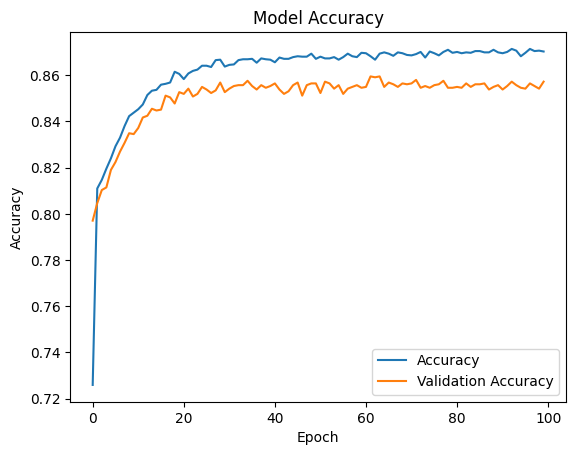

In [ ]:
plt.plot(history.history['accuracy'], label = "Accuracy")
plt.plot(history.history['val_accuracy'], label = "Validation Accuracy")
plt.legend()
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')